# Visualização de carregamento máximo de uma Linha de Transmissão Aérea

Emprego de fasores para visualizar os limites de carregamento

Transmission Line Parameters:
                    Parameter                  Value Unit
         Series Impedance (z)         0.1018+0.4894j Ω/km
         Shunt Admittance (y) 0.0000e+00+3.3753e-06j S/km
     Propagation Constant (γ)     0.000133+0.001292j 1/km
Characteristic Impedance (Zc)          382.81-39.39j    Ω
         Nominal Voltage (Vn)                    230   kV
           Natural Power (Pn)                  138.2   MW
       Nominal Current (inom)                    640    A

Example Analysis:


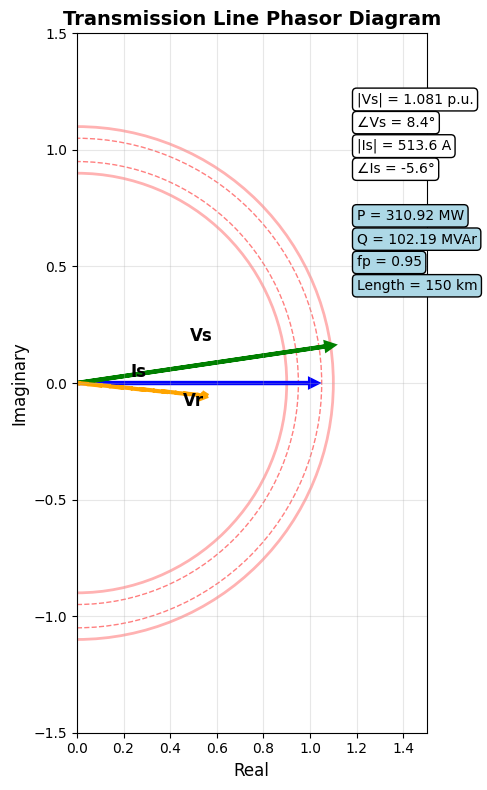


Loss Analysis for 150 km line:
Sending Power: 214.72 MW
Receiving Power: 310.92 MW
Line Losses: -96.20 MW
Efficiency: 144.80%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

class TransmissionLineAnalysis:
    def __init__(self):
        # Transmission Line Parameters
        self.z = 0.1018 + 1j*0.4894  # Series impedance per unit length [Ω/km]
        self.y = 1j*3.3753e-6        # Shunt admittance per unit length [S/km]
        self.gamma = np.sqrt(self.z * self.y)  # Propagation constant
        self.Zc = np.sqrt(self.z / self.y)     # Characteristic impedance
        self.Vn = 230e3                        # Nominal voltage [V]
        self.Pn = self.Vn**2 / self.Zc.real   # Natural power [W]
        self.inom = 640                        # Nominal conductor current [A]
        
        # Display parameters
        self.display_parameters()
    
    def display_parameters(self):
        """Display transmission line parameters"""
        print("Transmission Line Parameters:")
        print("="*50)
        
        params = {
            'Parameter': ['Series Impedance (z)', 'Shunt Admittance (y)', 
                         'Propagation Constant (γ)', 'Characteristic Impedance (Zc)',
                         'Nominal Voltage (Vn)', 'Natural Power (Pn)', 
                         'Nominal Current (inom)'],
            'Value': [f"{self.z:.4f}", f"{self.y:.4e}", f"{self.gamma:.6f}",
                     f"{self.Zc:.2f}", f"{self.Vn/1000:.0f}", 
                     f"{self.Pn/1e6:.1f}", f"{self.inom:.0f}"],
            'Unit': ['Ω/km', 'S/km', '1/km', 'Ω', 'kV', 'MW', 'A']
        }
        
        df = pd.DataFrame(params)
        print(df.to_string(index=False))
        print("="*50)
    
    def calculate_transmission_line(self, x, Vr=1.0, pn=1.0, fp=0.95, power_factor_type=-1):
        """
        Calculate transmission line parameters
        
        Parameters:
        x: Line length [km]
        Vr: Receiving voltage [p.u.]
        pn: Power loading [p.u.]
        fp: Power factor
        power_factor_type: -1 for lagging, 1 for leading
        """
        # Calculate transmission line constants
        gamma = np.sqrt(self.z * self.y)
        zc = np.sqrt(self.z / self.y)
        p = self.Vn**2 / zc.real
        
        # ABCD parameters
        a = np.cosh(gamma * x)
        b = zc * np.sinh(gamma * x)
        c = (1/zc) * np.sinh(gamma * x)
        
        # Receiving end conditions
        vr = Vr * self.Vn
        sr = (p * pn) / fp
        sr = sr * np.exp(-power_factor_type * 1j * np.arccos(fp))
        ir = np.conj(sr) / (np.sqrt(3) * vr)
        
        # Sending end calculations
        vs = a * vr + b * ir
        is_send = c * vr + a * ir
        
        # Normalized values for plotting
        vsr = vs.real / self.Vn
        vsi = vs.imag / self.Vn
        isr = is_send.real / self.inom
        isi = is_send.imag / self.inom
        
        # Calculate magnitudes and angles
        vs_abs = abs(vs / self.Vn)
        vs_arg = np.angle(vs) * 180 / np.pi
        is_abs = abs(is_send)
        is_arg = np.angle(is_send) * 180 / np.pi
        
        return {
            'vs': vs, 'is': is_send, 'vr': vr, 'ir': ir, 'sr': sr,
            'vsr': vsr, 'vsi': vsi, 'isr': isr, 'isi': isi,
            'vs_abs': vs_abs, 'vs_arg': vs_arg, 'is_abs': is_abs, 'is_arg': is_arg,
            'power_mw': sr.real * pn / 1e6, 'power_mvar': sr.imag * pn / 1e6
        }
    
    def plot_phasor_diagram(self, x, Vr=1.0, pn=1.0, fp=0.95, power_factor_type=-1):
        """Create phasor diagram plot"""
        
        results = self.calculate_transmission_line(x, Vr, pn, fp, power_factor_type)
        
        # Dynamic scaling for current vector
        max_val = max(abs(results['vsr']), abs(results['vsi']), 1.2)
        scale_factor = 0.8 / max_val
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Voltage limit circles
        circle1 = Circle((0, 0), 0.9, fill=False, color='red', alpha=0.3, linewidth=2)
        circle2 = Circle((0, 0), 1.1, fill=False, color='red', alpha=0.3, linewidth=2)
        circle3 = Circle((0, 0), 0.95, fill=False, color='red', alpha=0.5, linestyle='--')
        circle4 = Circle((0, 0), 1.05, fill=False, color='red', alpha=0.5, linestyle='--')
        
        ax.add_patch(circle1)
        ax.add_patch(circle2)
        ax.add_patch(circle3)
        ax.add_patch(circle4)
        
        # Voltage vectors
        ax.arrow(0, 0, Vr, 0, head_width=0.03, head_length=0.03, 
                fc='blue', ec='blue', linewidth=3, label='Vr')
        ax.arrow(0, 0, results['vsr'], results['vsi'], head_width=0.03, head_length=0.03,
                fc='green', ec='green', linewidth=3, label='Vs')
        
        # Current vector (scaled)
        ax.arrow(0, 0, scale_factor*results['isr'], scale_factor*results['isi'],
                head_width=0.03, head_length=0.03, fc='orange', ec='orange',
                linewidth=3, linestyle='--', label='Is (scaled)')
        
        # Labels
        ax.text(Vr/2, -0.1, 'Vr', fontsize=12, fontweight='bold', ha='center')
        ax.text(results['vsr']/2, results['vsi']/2 + 0.1, 'Vs', 
               fontsize=12, fontweight='bold', ha='center')
        ax.text(scale_factor*results['isr']/2, scale_factor*results['isi']/2 + 0.05,
               'Is', fontsize=12, fontweight='bold', ha='center')
        
        # Results display
        text_x, text_y = 1.2, 1.2
        ax.text(text_x, text_y, f"|Vs| = {results['vs_abs']:.3f} p.u.", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))
        ax.text(text_x, text_y-0.1, f"∠Vs = {results['vs_arg']:.1f}°", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))
        ax.text(text_x, text_y-0.2, f"|Is| = {results['is_abs']:.1f} A", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))
        ax.text(text_x, text_y-0.3, f"∠Is = {results['is_arg']:.1f}°", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white"))
        
        # Power information
        ax.text(text_x, text_y-0.5, f"P = {results['power_mw']:.2f} MW", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        ax.text(text_x, text_y-0.6, f"Q = {results['power_mvar']:.2f} MVAr", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        ax.text(text_x, text_y-0.7, f"fp = {fp:.2f}", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        ax.text(text_x, text_y-0.8, f"Length = {x:.0f} km", 
               fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
        
        # Plot formatting
        ax.set_xlim(0, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xlabel('Real', fontsize=12)
        ax.set_ylabel('Imaginary', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.set_title('Transmission Line Phasor Diagram', fontsize=14, fontweight='bold')
        ax.set_aspect('equal')
        
        plt.tight_layout()
        plt.show()
    
    def calculate_losses(self, x, Vr=1.0, pn=1.0, fp=0.95, power_factor_type=-1):
        """Calculate line losses"""
        
        results = self.calculate_transmission_line(x, Vr, pn, fp, power_factor_type)
        
        # Power calculations
        p_send = (np.sqrt(3) * results['vs'] * np.conj(results['is'])).real / 1e6
        p_rec = results['sr'].real * pn / 1e6
        losses = p_send - p_rec
        
        return {
            'p_send_mw': p_send,
            'p_rec_mw': p_rec,
            'losses_mw': losses,
            'efficiency': (p_rec/p_send)*100 if p_send != 0 else 0
        }
    
    def create_interactive_plot(self):
        """Create interactive plot using ipywidgets"""
        
        # Create widgets
        length_slider = widgets.FloatSlider(
            value=150, min=120, max=200, step=5,
            description='Length (km):', style={'description_width': 'initial'}
        )
        
        voltage_slider = widgets.FloatSlider(
            value=1.0, min=0.9, max=1.1, step=0.05,
            description='Receiving Voltage (p.u.):', style={'description_width': 'initial'}
        )
        
        power_slider = widgets.FloatSlider(
            value=1.0, min=1.0, max=3.0, step=0.1,
            description='Power Loading (p.u.):', style={'description_width': 'initial'}
        )
        
        pf_slider = widgets.FloatSlider(
            value=0.95, min=0.8, max=1.0, step=0.05,
            description='Power Factor:', style={'description_width': 'initial'}
        )
        
        pf_type = widgets.RadioButtons(
            options=[('Lagging', -1), ('Leading', 1)],
            value=-1, description='Power Factor Type:'
        )
        
        def update_plot(*args):
            clear_output(wait=True)
            self.plot_phasor_diagram(
                length_slider.value, voltage_slider.value, 
                power_slider.value, pf_slider.value, pf_type.value
            )
            
            # Display losses
            losses = self.calculate_losses(
                length_slider.value, voltage_slider.value,
                power_slider.value, pf_slider.value, pf_type.value
            )
            
            print(f"\nLoss Analysis:")
            print(f"Sending Power: {losses['p_send_mw']:.2f} MW")
            print(f"Receiving Power: {losses['p_rec_mw']:.2f} MW") 
            print(f"Line Losses: {losses['losses_mw']:.2f} MW")
            print(f"Efficiency: {losses['efficiency']:.2f}%")
        
        # Connect widgets to update function
        length_slider.observe(update_plot, 'value')
        voltage_slider.observe(update_plot, 'value')
        power_slider.observe(update_plot, 'value')
        pf_slider.observe(update_plot, 'value')
        pf_type.observe(update_plot, 'value')
        
        # Display widgets and initial plot
        controls = widgets.VBox([
            length_slider, voltage_slider, power_slider, pf_slider, pf_type
        ])
        
        display(controls)
        update_plot()

# Usage example
if __name__ == "__main__":
    # Create transmission line analysis instance
    tl_analysis = TransmissionLineAnalysis()
    
    # Example: Plot with specific parameters
    print("\nExample Analysis:")
    tl_analysis.plot_phasor_diagram(x=150, Vr=1.0, pn=1.5, fp=0.95, power_factor_type=-1)
    
    # Calculate and display losses
    losses = tl_analysis.calculate_losses(x=150, Vr=1.0, pn=1.5, fp=0.95, power_factor_type=-1)
    print(f"\nLoss Analysis for 150 km line:")
    print(f"Sending Power: {losses['p_send_mw']:.2f} MW")
    print(f"Receiving Power: {losses['p_rec_mw']:.2f} MW") 
    print(f"Line Losses: {losses['losses_mw']:.2f} MW")
    print(f"Efficiency: {losses['efficiency']:.2f}%")
    
    # Uncomment the line below to create interactive plot (requires Jupyter notebook)
    # tl_analysis.create_interactive_plot()

In [2]:
create_interactive_plot()

NameError: name 'create_interactive_plot' is not defined